# NLP Portion

In [11]:
%pip install gdown pandas numpy seaborn matplotlib PyPDF2 langdetect gensim nltk

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gdown
import re
import os
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

True

In [13]:

# Define the correct path for the merged dataset
MERGED_FILE = "/content/merged_dataset.xlsx"
# interview_data https://docs.google.com/spreadsheets/d/1pqqEJKtKnpvzjHQxAlfn4XG3hYmtc_tG/edit?usp=sharing&ouid=109332598743890107845&rtpof=true&sd=true
# raw_metadata https://docs.google.com/spreadsheets/d/1EylkR8vtQZpZm2aOjhlqKo9sUM8VN2SM/edit?usp=sharing&ouid=109332598743890107845&rtpof=true&sd=true

interview_data_file = '1pqqEJKtKnpvzjHQxAlfn4XG3hYmtc_tG'
raw_metadata_file = '1EylkR8vtQZpZm2aOjhlqKo9sUM8VN2SM'

gdown.download(id=interview_data_file, output='interview_data.xlsx', quiet=False)
gdown.download(id=raw_metadata_file, output='raw_metadata.xlsx', quiet=False)

df_interview = pd.read_excel('interview_data.xlsx')
df_metadata = pd.read_excel('raw_metadata.xlsx')

Downloading...
From: https://drive.google.com/uc?id=1pqqEJKtKnpvzjHQxAlfn4XG3hYmtc_tG
To: /Users/rlay/work/26s-curric-803-report/interview_data.xlsx
100%|██████████| 1.67M/1.67M [00:00<00:00, 5.87MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EylkR8vtQZpZm2aOjhlqKo9sUM8VN2SM
To: /Users/rlay/work/26s-curric-803-report/raw_metadata.xlsx
100%|██████████| 20.8k/20.8k [00:00<00:00, 813kB/s]


In [14]:
df_interview.head()

,Unnamed: 0,interview_id,narrator_name,interviewer_name,date,location,interview_length,sub-collection,narrator_initials,interviewer_initials,narrator_dialogue,interviewer_dialogue
0,0,VAOHP0101,Mary Hoang Long,Nina Mai Thi Long,"November 13, 2012","Westminster, California",01:32:16,"Vietnamese American Experience Course, Fall 2012",MHL,NL,Hi Nina. My full name is Mary Hoang Long. I am...,"Today is Tuesday, November 13, 2012. This is N..."
1,1,VAHF0002,Charlie Van Le,Pham Quang Tuan,"November 5, 2010","Westminster, California",00:12:13,Vietnamese American Heritage Foundation 500 Or...,CVL,PQT,"Right now, I just graduated from the Universit...",I’d like to ask you if you can state your name...
2,2,VAOHP0111,Alex Thai Nguyen,Samantha Erica Takahashi,"February 10, 2013","Westminster, California",01:19:24,"Linda Vo Class Oral Histories, 2013",ATN,SET,"Yes, my name is Alex Thai Nguyen. A-L-E-X Thai...","Today is Sunday, February 10, 2013. This is Sa..."
3,3,VAHF0010,Nguyễn Thị Hạnh Nhơn (Nthn),Nancy Bui/Trieu Giang (Tg) Date Of Interview: ...,NaN,NaN,01:23:22,Vietnamese American Heritage Foundation 500 Or...,NTHN,TG,"Yes, my dear . My name is Nguyễn thi Hanh Nhon...",Mrs Nguyễn Hạnh Nhơn . Can you let us know whe...
4,4,VAOHP0100,Thomas Toan Phan,Winty Thoumaked,"November 15, 2012","Westminster, California",01:06:50,"Vietnamese American Experience Course, Fall 2012",TP,WT,My name is Thomas Toan Phan. My date of birth ...,Hello my name is Winty Thoumaked and today is ...


In [15]:
df_metadata.head()

,Interview_ID,Birth_Year,Birth_Year_Source,Year_Left_Country,Leave_Year_Source,Year_of_Arrival,Arrival_Year_Source,Year_of_Arrival_Inferred,Years_in_Transit,Age_at_Departure,...,Age_at_Arrival_Flag,Departure_Wave,Arrival_Wave,Wave,Wave_Source,Refugee_Cohort,Refugee_Cohort_Source,Gender,Gender_Source,Generation_Source
0,VAHF0001,1949.0,regex,NaN,NaN,1979.0,regex,0,NaN,NaN,...,0,NaN,Wave 2 (1979),Wave 2 (1979),arrival,NaN,NaN,Male,name_vn,NaN
1,VAHF0002,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,0,NaN,Wave 3 (ODP-era),Wave 3 (ODP-era),cohort,ODP,NaN,Male,name_vn,NaN
2,VAHF0003,1970.0,regex,1979.0,regex,1979.0,regex,0,0.0,9.0,...,0,Wave 2 (1979),Wave 2 (1979),Wave 2 (1979),cohort,Boat people,NaN,Male,name_vn,NaN
3,VAHF0005,1984.0,regex,NaN,NaN,1975.0,regex,0,NaN,NaN,...,1,NaN,Wave 1 (1975),Wave 1 (1975),arrival,NaN,NaN,Female,title,NaN
4,VAHF0006,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,0,NaN,Wave 1 (1975),Wave 1 (1975),cohort,Fall of Saigon (1975),NaN,Male,pronoun_companion,NaN


In [16]:
# Merge: df_interview into df_metadata
df_merged = df_metadata.merge(df_interview, 
                          left_on='Interview_ID', 
                          right_on='interview_id', 
                          how='left')

df_merged.columns = df_merged.columns.str.lower()

print(f"Merged dataframe shape: {df_merged.shape}")
print("Merged dataframe columns:", df_merged.columns.tolist())

df_merged.to_excel('merged_interview_metadata.xlsx')

Merged dataframe shape: (195, 33)
Merged dataframe columns: ['interview_id', 'birth_year', 'birth_year_source', 'year_left_country', 'leave_year_source', 'year_of_arrival', 'arrival_year_source', 'year_of_arrival_inferred', 'years_in_transit', 'age_at_departure', 'age_at_arrival', 'age_at_arrival_flag', 'departure_wave', 'arrival_wave', 'wave', 'wave_source', 'refugee_cohort', 'refugee_cohort_source', 'gender', 'gender_source', 'generation_source', 'unnamed: 0', 'interview_id', 'narrator_name', 'interviewer_name', 'date', 'location', 'interview_length', 'sub-collection', 'narrator_initials', 'interviewer_initials', 'narrator_dialogue', 'interviewer_dialogue']


In [17]:
df_merged.head()

,interview_id,birth_year,birth_year_source,year_left_country,leave_year_source,year_of_arrival,arrival_year_source,year_of_arrival_inferred,years_in_transit,age_at_departure,...,narrator_name,interviewer_name,date,location,interview_length,sub-collection,narrator_initials,interviewer_initials,narrator_dialogue,interviewer_dialogue
0,VAHF0001,1949.0,regex,NaN,NaN,1979.0,regex,0,NaN,NaN,...,Hồ Văn Khởi,Nancy Bùi,"May 25, 2010","San Jose, California",00:50:51,Vietnamese American Heritage Foundation 500 Or...,HVK,NB,"I’m Hồ Văn Khởi. I was born in Gò Công, Việt N...",Hello Sir! Would you please introduce your nam...
1,VAHF0002,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,Charlie Van Le,Pham Quang Tuan,"November 5, 2010","Westminster, California",00:12:13,Vietnamese American Heritage Foundation 500 Or...,CVL,PQT,"Right now, I just graduated from the Universit...",I’d like to ask you if you can state your name...
2,VAHF0003,1970.0,regex,1979.0,regex,1979.0,regex,0,0.0,9.0,...,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),Darlena Tran,"November 07, 2010","Westminster, California Length of Interview: 0...",NaN,Vietnamese American Heritage Foundation 500 Or...,HVC,DT,"My name is Huynh Van Chinh, I have been perfor...",What is your name? Where were you born? How is...
3,VAHF0005,1984.0,regex,NaN,NaN,1975.0,regex,0,NaN,NaN,...,Tiffany Le,Roger Le,"November 10, 2010","Westminster, California",01:05:18,Vietnamese American Heritage Foundation 500 Or...,TL,RL,My name is Tiffany Le. I was born in Riverside...,"Hi, name is Roger Le and today is November 10,..."
4,VAHF0006,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,Roger Minh Le,Tuan Quang Pham,"November 5, 2010","Westminster, California",00:17:49,Vietnamese American Heritage Foundation 500 Or...,RL,PQT,"My name’s Roger Minh Le, I’m 24, and I current...",My name is Tuan Quang Pham and today’s day is ...


In [ ]:
# drop 
df_filtered = df_merged[[
    "interview_id",
    "birth_year",
    "gender",
    "wave",
    "narrator_dialogue",
    "narrator_name"
]].copy()

# Drop duplicate interview_id column if it exists
if df_filtered.columns.duplicated().any():
    df_filtered = df_filtered.loc[:, ~df_filtered.columns.duplicated()]

# Drop empty narrator_dialogue if it exists
df_filtered = df_filtered.dropna(subset=["narrator_dialogue"])

display(df_filtered.shape)
display(df_filtered.head())


(127, 6)

,interview_id,birth_year,gender,wave,narrator_dialogue,narrator_name
0,VAHF0001,1949.0,Male,Wave 2 (1979),"I’m Hồ Văn Khởi. I was born in Gò Công, Việt N...",Hồ Văn Khởi
1,VAHF0002,NaN,Male,Wave 3 (ODP-era),"Right now, I just graduated from the Universit...",Charlie Van Le
2,VAHF0003,1970.0,Male,Wave 2 (1979),"My name is Huynh Van Chinh, I have been perfor...",Huỳnh Văn Chỉnh (Aka Trung Chỉnh)
3,VAHF0005,1984.0,Female,Wave 1 (1975),My name is Tiffany Le. I was born in Riverside...,Tiffany Le
4,VAHF0006,NaN,Male,Wave 1 (1975),"My name’s Roger Minh Le, I’m 24, and I current...",Roger Minh Le


In [19]:
# keep only rows where narrator_dialogue is detected as English
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

def is_english(text):
    return detect(str(text)) == "en"

df_filtered = (
    df_filtered
      .copy()
      .assign(_is_en=df_filtered["narrator_dialogue"].fillna("").apply(is_english))
      .query("_is_en")
      .drop(columns="_is_en")
      .reset_index(drop=True)
)

print("Rows after English-only filter:", len(df_filtered))

Rows after English-only filter: 121


In [20]:
# remove interview_id header from the transcript
df_filtered['narrator_dialogue'] = df_filtered['narrator_dialogue'].apply(
    lambda x: re.sub(r"(VA[A-Z]+\d+(?:\.\d+)?)", "", x))
display(df_filtered['narrator_dialogue'][0])


'I’m Hồ Văn Khởi. I was born in Gò Công, Việt Nam. I was born in 1949. I lived there when I was young. I went to elementary school there in Gò Công, in the countryside, but when I went to high school as I grew up I came to Saigon. When I was young my family was very poor, so I went to school and took care of my siblings; therefore, I hardly had any children’s game, and if there was any, it would just be as normal as any other kid, nothing special to remember. My parents had 10 of us. I’m the oldest in my family. Like other people, to me my parents are my role models, ideal and above all. I have a special memory of my parents, and that is in front of their children they hardly ever argued with each other. There was a time when I came across a situation, it was at night when I went out and saw my parents talking to each other about things that they disagreed on. Things that were big or small, they talked to each other privately rather than in front of their children. That was something t

In [21]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.models import TfidfModel
from gensim.corpora import Dictionary
import string
import random
import unicodedata

In [22]:
# Custom Preprocessing so that we can normalize place names
# English stopwords
EN_STOPWORDS = set(stopwords.words("english"))

ORAL_STOPWORDS = {
    # Filler words
    "uh", "um", "umm", "oh", "okay", "ok", "yeah", "uhuh", "yea",
    "laughs", "laughter",
    # Contractions
    "dont", "didnt", "wasnt", "thats", "theyre", "ive", "im",
    "youre", "were", "weve", "its", "theres", "cannot",
    # High-frequency verbs
    "like", "know", "got", "get", "go", "going", "went", "come", "came",
    "said", "say", "think", "thought", "make", "made", "want",
    # Modal / auxiliary
    "would", "could",
    # Adverbs / hedges
    "just", "really", "actually", "still", "even", "always", "never",
    "already", "also", "back", "around", "well", "probably", "basically",
    "definitely", "mean", "sort", "guess",
    # Vague quantifiers
    "lot", "something", "everything", "anything", "everybody",
    "couple", "stuff",
    # Generic adjectives
    "good", "little", "big", "old", "new", "right", "long", "growing",
    # Generic nouns
    "people", "thing", "things", "one", "two", "three", "way",
}

STOPWORDS = EN_STOPWORDS | ORAL_STOPWORDS

# ---------------------------------------------------------------------------
# City / place name normalization
# Order matters: longer / more specific patterns first to avoid partial matches
# ---------------------------------------------------------------------------
PLACE_NORMALIZER = [
    # Ho Chi Minh City variants → saigon (more common in refugee narratives)
    (re.compile(r"\bthành\s+phố\s+hồ\s+chí\s+minh\b", re.IGNORECASE), "saigon"),  # full Vietnamese name first
    (re.compile(r"\bho\s+chi\s+minh\s+city\b",          re.IGNORECASE), "saigon"),
    (re.compile(r"\bho\s+chi\s+minh\b",                 re.IGNORECASE), "saigon"),
    (re.compile(r"\bhochi\s*minh\b",                    re.IGNORECASE), "saigon"),
    (re.compile(r"\bsài\s+gòn\b",                       re.IGNORECASE), "saigon"),  # full diacritic
    (re.compile(r"\bsài\s+gon\b",                       re.IGNORECASE), "saigon"),  # mixed diacritic
    (re.compile(r"\bsai\s+gòn\b",                       re.IGNORECASE), "saigon"),  # mixed diacritic
    (re.compile(r"\bsai\s+gon\b",                       re.IGNORECASE), "saigon"),  # no diacritic

    # Hanoi variants
    (re.compile(r"\bhà\s+nội\b",  re.IGNORECASE), "hanoi"),  # full diacritic
    (re.compile(r"\bhà\s+noi\b",  re.IGNORECASE), "hanoi"),  # mixed diacritic
    (re.compile(r"\bha\s+nội\b",  re.IGNORECASE), "hanoi"),  # mixed diacritic
    (re.compile(r"\bha\s+noi\b",  re.IGNORECASE), "hanoi"),  # no diacritic
    (re.compile(r"\bha-noi\b",    re.IGNORECASE), "hanoi"),  # hyphenated

    # Da Nang variants
    (re.compile(r"\bđà\s+nẵng\b", re.IGNORECASE), "danang"),  # full Vietnamese
    (re.compile(r"\bda\s+nang\b", re.IGNORECASE), "danang"),
    (re.compile(r"\bda-nang\b",   re.IGNORECASE), "danang"),

    # Hue variants
    (re.compile(r"\bhu[eế]\b",    re.IGNORECASE), "hue"),

    # Vung Tau
    (re.compile(r"\bv[uũ]ng\s+tàu\b", re.IGNORECASE), "vungtau"),  # diacritic
    (re.compile(r"\bv[uũ]ng\s+tau\b",  re.IGNORECASE), "vungtau"),  # no diacritic

    # Mekong Delta
    (re.compile(r"\bmekong\s+delta\b", re.IGNORECASE), "mekongdelta"),

    # Phnom Penh variants
    (re.compile(r"\bphnom\s+penh\b",  re.IGNORECASE), "phnompenh"),
    (re.compile(r"\bpnom\s+penh\b",   re.IGNORECASE), "phnompenh"),

    # Vientiane variants
    (re.compile(r"\bvien\s+chan\b",   re.IGNORECASE), "vientiane"),

    # United States variants
    (re.compile(r"\bunited\s+states\b", re.IGNORECASE), "unitedstates"),
    (re.compile(r"\bu\.s\.a\b",         re.IGNORECASE), "unitedstates"),
    (re.compile(r"\bu\.s\.\b",          re.IGNORECASE), "unitedstates"),
]

# ---------------------------------------------------------------------------
# Interview ID pattern — covers all known archive prefixes
# VAHF, VAOHP, VAOHA, VOA, and any VA-prefixed collection IDs
# Applied AFTER lowercasing so match is case-insensitive by construction
# ---------------------------------------------------------------------------
interview_id_regex = re.compile(
    r"^(?:va(?:ohp|hf|oha|hp|oh|aohp)?|voa(?:ohp|hf|hp)?)\d+(?:\.\d+)?$" #oh|aohp|ohvaohp0019 => edit
)

def normalize_places(text: str) -> str:
    """Replace multi-word and variant place names with a single canonical token."""
    # NFC normalization ensures diacritics are stored as composed characters
    text = unicodedata.normalize("NFC", text)
    for pattern, canonical in PLACE_NORMALIZER:
        text = pattern.sub(canonical, text)
    return text

translator = str.maketrans("", "", string.punctuation)

def preprocess_tokens(text: str) -> list:
    # Normalize curly/smart apostrophes and quotes
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')

    # Normalize place names BEFORE stripping punctuation
    text = normalize_places(text)

    # Strip punctuation and lowercase
    text = text.translate(translator).lower()

    tokens = [
        t for t in text.split()
        if (
            t not in STOPWORDS
            and not interview_id_regex.match(t)
            and len(t) > 2
            and not re.match(r"^\d+$", t)
        )
    ]
    return tokens


In [23]:
# run pre-processing
processed_corpus = [preprocess_tokens(sentence) for sentence in df_filtered["narrator_dialogue"]]

# building vocabulary (unique words)
vocabulary = set()
for sentence in processed_corpus:
    vocabulary.update(sentence)
vocabulary = sorted(list(vocabulary))

vocabulary_count = {word: sum(word in sentence for sentence in processed_corpus) for word in vocabulary}
vocabulary_count = dict(sorted(vocabulary_count.items(), key=lambda x: x[1], reverse=True))
display(vocabulary_count)

{'time': 119,
 'vietnamese': 117,
 'school': 115,
 'vietnam': 115,
 'family': 114,
 'years': 114,
 'first': 112,
 'year': 110,
 'born': 108,
 'much': 108,
 'yes': 108,
 'work': 107,
 'name': 105,
 'parents': 104,
 'remember': 104,
 'see': 103,
 'saigon': 101,
 'american': 99,
 'home': 99,
 'left': 99,
 'life': 98,
 'live': 98,
 'lived': 98,
 'took': 97,
 'friends': 96,
 'high': 95,
 'different': 94,
 'young': 94,
 'english': 93,
 'every': 93,
 'away': 92,
 'day': 92,
 'take': 92,
 'brother': 91,
 'house': 91,
 'many': 91,
 'war': 91,
 'job': 90,
 'father': 88,
 'hard': 88,
 'months': 88,
 'college': 87,
 'called': 86,
 'food': 86,
 'help': 85,
 'told': 85,
 'mom': 84,
 'sister': 84,
 'worked': 84,
 'camp': 83,
 'care': 81,
 'country': 81,
 'money': 81,
 'city': 80,
 'moved': 80,
 'nothing': 80,
 'older': 80,
 'south': 80,
 'kids': 79,
 'kind': 79,
 'last': 79,
 'stayed': 79,
 'talk': 79,
 'younger': 79,
 'ask': 78,
 'children': 78,
 'later': 78,
 'learn': 78,
 'living': 78,
 'put': 78,

In [24]:
# # catch bigrams (don't run this, not complete yettttt)
# # building vocabulary (unique bigrams)
# vocabulary = set()
# for sentence in processed_corpus:
#     for i in range(len(sentence) - 1):
#         vocabulary.add(sentence[i] + ' ' + sentence[i+1])
# vocabulary = sorted(list(vocabulary))

# vocabulary_count = {bigram: sum(bigram in ' '.join(sentence) for sentence in processed_corpus) for bigram in vocabulary}
# vocabulary_count = dict(sorted(vocabulary_count.items(), key=lambda x: x[1], reverse=True))
# display(vocabulary_count)

,interviewee,narrator_dialogue,num_words,avg_word_length,num_sentences,avg_sentence_length,complexity
112,David Nguyen,"Uh sure, before my parents immigrated from Vie...",980,6.553061,139,26.395683,22.632760
32,Tuan Anh Le,"My name’s Tuan. Last name Le, Le. Middle name ...",1943,5.295934,179,37.184358,22.106028
46,Anthony Leduc,"My name is Anthony LeDuc, a name I took when I...",441,6.272109,36,27.055556,21.639410
87,Steven Bui,My name is Steven Bui; I was born in December ...,674,5.578635,71,32.126761,20.908751
28,Minh Hanh Nguyen,"Minh Hanh Nguyen January 12, 1942 in Saigon, V...",2033,6.202656,267,24.059925,19.814473
100,Ken To (Cuong Vinh To),"My name is Ken, last name is To, and my Vietna...",2013,5.627422,227,29.242291,19.696302
85,Cuong C. Tran,"My name is Cuong, like Vietnamese is spel led ...",547,5.588665,64,29.593750,19.689489
9,Henry Wong,"My name is Henry Wong, I am 51 years old, and ...",1755,6.139601,209,23.588517,19.281780
4,Roger Minh Le,"My name’s Roger Minh Le, I’m 24, and I current...",575,6.340870,81,21.580247,19.225619
98,Haonhien Vu,Well you're certainly welcome got to do th is....,146,5.691781,18,27.666667,19.211621


<Axes: xlabel='complexity', ylabel='Count'>

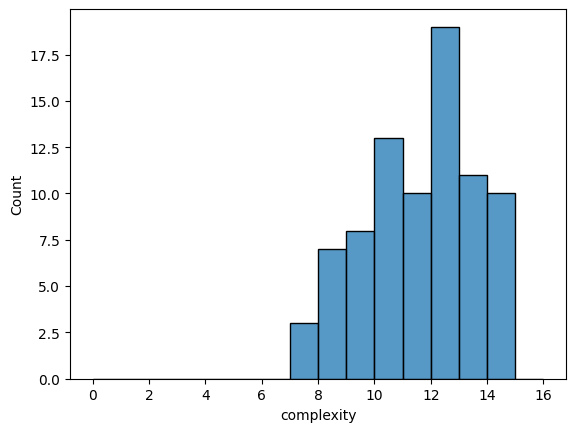

In [26]:
# --- keep alignment between filtered_df, processed_df, and dataset ---
processed_df = df_filtered.reset_index(drop=True)

# narrator name column may differ across your merges; use whichever exists
name_col = "narrator_name" if "narrator_name" in processed_df.columns else (
    "table_details_narrator_name" if "table_details_narrator_name" in processed_df.columns else None
)

df_new = pd.DataFrame({
    "interviewee": processed_df[name_col] if name_col else np.arange(len(processed_df)),
    "narrator_dialogue": processed_df["narrator_dialogue"]
})

# dataset is list-of-token-lists built from filtered_df["narrator_dialogue"]
dataset_df = pd.DataFrame({"tokens": processed_corpus})

# --- word-level metrics (safe when token list is empty) ---
df_new["num_words"] = dataset_df["tokens"].apply(len)

df_new["avg_word_length"] = dataset_df["tokens"].apply(
    lambda toks: (sum(len(w) for w in toks) / len(toks)) if len(toks) > 0 else 0.0
)

# --- sentence-level metrics (use RAW narrator dialogue, not tokenized dataset) ---
text_series = processed_df["narrator_dialogue"].fillna("").astype(str)

sentence_list = (
    text_series
      .str.replace(r"[?!]+", ".", regex=True)   # replace ? and ! properly
      .str.split(".")
      .apply(lambda sents: [s.strip() for s in sents if s and s.strip()])  # drop blanks
)

df_new["num_sentences"] = sentence_list.apply(len)

df_new["avg_sentence_length"] = sentence_list.apply(
    lambda sents: (sum(len(sent.split()) for sent in sents) / len(sents)) if len(sents) > 0 else 0.0
)

# --- ARI (don't round until display; rounding early hides variation) ---
df_new["complexity"] = (
    4.71 * df_new["avg_word_length"]
    + 0.5 * df_new["avg_sentence_length"]
    - 21.43
)

# inspect outliers
display(df_new[df_new["complexity"] > 14].sort_values("complexity", ascending=False).head(30))

# plot "reasonable" values
sns.histplot(df_new[df_new["complexity"] < 15], x="complexity", bins=np.arange(0, 17, 1.0))

In [27]:
lowest_complexity_person = df_new.loc[df_new["complexity"].idxmin(), "interviewee"]
lowest_complexity_transcript = processed_df.loc[df_new["complexity"].idxmin(), "narrator_dialogue"]

print(lowest_complexity_transcript)
print(detect(str(lowest_complexity_transcript)) == "en")

My name is Nhu Tong. I’m 56 years old. I was born in a small town in Viet Nam. It is small, but it is a famous city. I was born and My parents, my father passed away and my mom’s still alive and she lives with us and My parents are very like strict. They have home rules but to the you know the children. We I grow up in that city, that small city since young until I left the city and left the house to In the, you know Nha Trang. When I work, I work in Nha Trang city. But I was born in the Over there in Hue city. The college in Hue city. I study medicine. Yes. I got a degree from there. A degree, a medical doctor. And then I went to Nha Trang Yes. That’s the journey to be here. Yeah a lot of childhood memories, but you know when I was small, very little, like under And we have the fruit trees and the flower Plumeria and we have a lot. We pick the flower Underneath the floor and go over something on it. But we have a way to go down there. Yeah, scared. And then we went to school. Do every

In [28]:
df_new.to_excel('df_new.xlsx')

,wave,gender,n,mean,median,sd
0,Wave 1 (1975),Female,9,11.751438,11.688444,1.660435
1,Wave 1 (1975),Male,20,12.555916,13.457845,2.212229
2,Wave 2 (1979),Female,9,10.585847,8.784367,2.830413
3,Wave 2 (1979),Male,19,11.117342,11.187641,1.548749
4,Wave 3 (ODP-era),Female,5,12.052662,12.049927,1.248731
5,Wave 3 (ODP-era),Male,8,12.287437,12.400268,1.287274


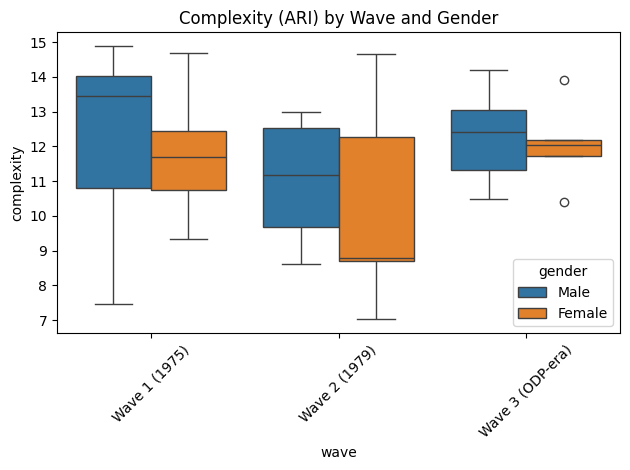

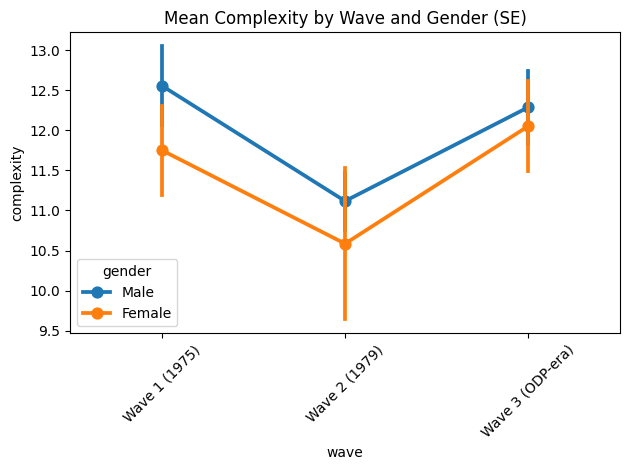

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Attach gender + wave to df_new (already aligned by index)
df_new["gender"] = processed_df["gender"]
df_new["wave"]   = processed_df["wave"]

# Drop missing values
plot_df = df_new.dropna(subset=["complexity", "gender", "wave"]).copy()

# Optional: keep only reasonable ARI range
plot_df = plot_df[(plot_df["complexity"] > -50) & (plot_df["complexity"] < 15)]

# --- Force wave ordering ---
wave_order = ["Wave 1 (1975)", "Wave 2 (1979)", "Wave 3 (ODP-era)"]
plot_df["wave"] = pd.Categorical(plot_df["wave"],
                                  categories=wave_order,
                                  ordered=True)

# --- Summary table ---
summary = (
    plot_df
      .groupby(["wave", "gender"])["complexity"]
      .agg(n="size", mean="mean", median="median", sd="std")
      .reset_index()
      .sort_values(["wave", "gender"])
)

display(summary)

# --- Boxplot ---
plt.figure()
sns.boxplot(data=plot_df, x="wave", y="complexity", hue="gender")
plt.xticks(rotation=45)
plt.title("Complexity (ARI) by Wave and Gender")
plt.tight_layout()
plt.show()

# --- Mean comparison plot ---
plt.figure()
sns.pointplot(data=plot_df, x="wave", y="complexity", hue="gender", errorbar="se")
plt.xticks(rotation=45)
plt.title("Mean Complexity by Wave and Gender (SE)")
plt.tight_layout()
plt.show()

In [32]:
dct = Dictionary(processed_corpus)
print(dct)
corpus = [dct.doc2bow(line) for line in processed_corpus]
tfidf = TfidfModel(corpus)

Dictionary<14094 unique tokens: ['100s', '12th', '1st', '27th', '2nd']...>


In [33]:
d_i = random.randint(0,len(processed_corpus))
display(" ".join(processed_corpus[d_i]))
tfidf_indices = tfidf[corpus[d_i]]

'name steven bui born december 19th vietnam phan thiet vietnam father name first name bui mother name parent parent grew house war call mountain young nineteen sixty nine mountain parent left binh thuy phan thiet vietnam left wit hat business bought merchandise phan school vietnam school first eight ah…farmer main farmer yup mother farm farms daddy run business first yes every summer fair peopl gathering birthday celebrate birthday celebrate tet tet huc tet wish grand mar parents live longer healthy first life time read help aunt brick remember first working hard hard working person …like nine keep private oldest parent children time take play neighborhood play…and sure young young playing climb boat boat wheeling wheeling call vietnamese memory story recall recall mother side farmer farm none father escape communist south huh originally north vietnam north anoi close hue hue call parent meet middle heard somebody tet tet annually gathering time see america gathering eat cook eat cultu

In [34]:
display(list(map(lambda y: dct[y[0]], sorted(tfidf_indices,key=lambda x: x[1],reverse=True)[:10])))

['orleans',
 'huh',
 'parent',
 'thiet',
 'tet',
 'phan',
 'baptize',
 'delgado',
 'investor',
 'wheeling']

In [36]:
interview_enum = enumerate(processed_corpus)
interview_corpus = [TaggedDocument(doc, [i]) for i, doc in interview_enum]
# doc 2 vec turns the abstracts into lists of word vectors
model = Doc2Vec(interview_corpus, vector_size=2, window=2, min_count=1, workers=4)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [37]:
xs = []
ys = []
for doc in processed_corpus:
  vec = model[doc]
  # this is very rough - what's the midpoint of the abstract?
  xs.append(np.mean(vec[:,0]))
  ys.append(np.mean(vec[:,1]))
xs = np.array(xs)
ys = np.array(ys)

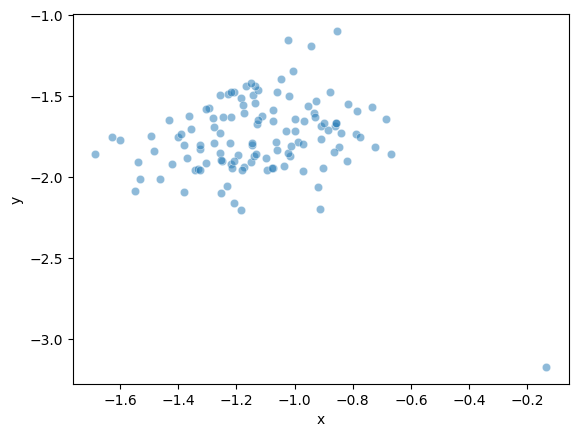

In [38]:
plotdf = pd.DataFrame({"x":xs,"y":ys})
g = sns.scatterplot(plotdf,x="x",y="y",alpha=0.5)
plt.show()

In [39]:
#Gemini assistance for this part
tfidf_corpus_scores = []
for doc in corpus:
    tfidf_corpus_scores.append(tfidf[doc])

print(f"Number of TFIDF score vectors generated: {len(tfidf_corpus_scores)}")
print("First TFIDF score vector (example):")
print(tfidf_corpus_scores[0])
most_significant_tfidf_words = [
    {
        'interviewee_name': processed_df.loc[i, 'narrator_name'],
        'most_significant_tfidf_word': dct[max(doc_scores, key=lambda item: item[1])[0]] if doc_scores else "N/A",
        'tfidf_score': max(doc_scores, key=lambda item: item[1])[1] if doc_scores else 0.0
    }
    for i, doc_scores in enumerate(tfidf_corpus_scores)
]

# Create DataFrame
most_significant_tfidf_words_df = pd.DataFrame(most_significant_tfidf_words)

# Display the DataFrame
display(most_significant_tfidf_words_df)

Number of TFIDF score vectors generated: 121
First TFIDF score vector (example):
[(0, np.float64(0.032388216453086024)), (1, np.float64(0.01924657515189817)), (2, np.float64(0.015606479704190492)), (3, np.float64(0.043037859054743596)), (4, np.float64(0.01683778244549306)), (5, np.float64(0.011212757602792075)), (6, np.float64(0.031212959408380984)), (7, np.float64(0.00860266792362723)), (8, np.float64(0.020287626786069227)), (9, np.float64(0.00877466564140495)), (10, np.float64(0.021850665244623514)), (11, np.float64(0.03646990609084298)), (12, np.float64(0.027707069371207288)), (13, np.float64(0.032388216453086024)), (14, np.float64(0.011827132566760105)), (15, np.float64(0.009196894851664108)), (16, np.float64(0.028198973884467467)), (17, np.float64(0.021518929527371798)), (18, np.float64(0.014099486942233733)), (19, np.float64(0.005703619701084213)), (20, np.float64(0.032388216453086024)), (21, np.float64(0.011212757602792075)), (22, np.float64(0.020769533565925896)), (23, np.float

,interviewee_name,most_significant_tfidf_word,tfidf_score
0,Hồ Văn Khởi,cadets,0.518211
1,Charlie Van Le,conduct,0.263585
2,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),medical,0.433764
3,Tiffany Le,boot,0.351659
4,Roger Minh Le,amarillo,0.284858
...,...,...,...
116,Naomi Ngoc Yen Quach,literally,0.294535
117,Sang Nguyen (Steven Thanh Nguyen),sons,0.292336
118,Lâm Lệ Thanh,to–,0.372424
119,Tran Ngoc Tu,connecticut,0.272707


In [40]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


,word,total_tfidf_score
0,pretty,2.438207
1,mom,2.312845
2,boat,2.230564
3,america,2.230375
4,mother,2.099830
5,dad,2.001623
6,husband,1.985852
7,country,1.937257
8,children,1.747717
9,money,1.721820


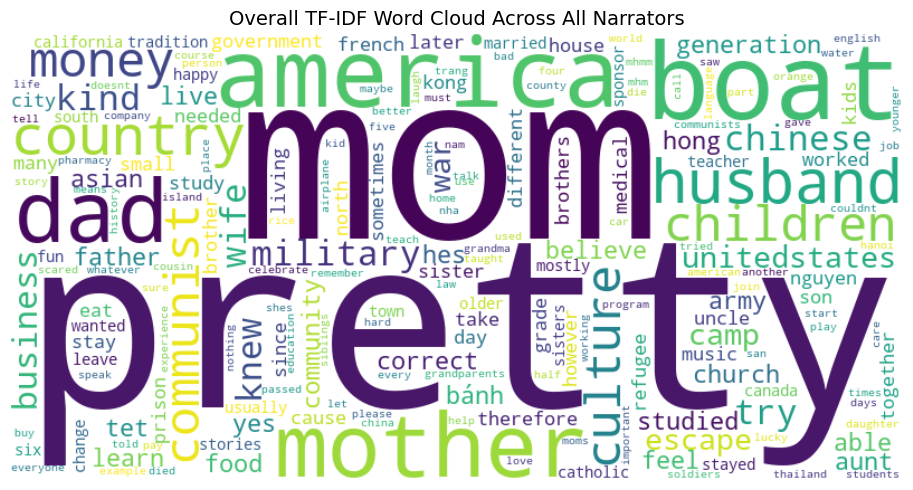

In [41]:
# Aggregate TF-IDF scores across ALL narrators
tfidf_corpus_scores = [tfidf[doc] for doc in corpus]

aggregated_scores = {}
for doc_scores in tfidf_corpus_scores:
    for word_id, score in doc_scores:
        word = dct[word_id]
        aggregated_scores[word] = aggregated_scores.get(word, 0) + score

# Sort by total TF-IDF score
overall_tfidf_df = (
    pd.DataFrame(
        aggregated_scores.items(),
        columns=["word", "total_tfidf_score"]
    )
    .sort_values("total_tfidf_score", ascending=False)
    .reset_index(drop=True)
)

display(overall_tfidf_df.head(50))

# Word cloud from overall TF-IDF
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(aggregated_scores)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Overall TF-IDF Word Cloud Across All Narrators", fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
display(overall_tfidf_df.tail(50))

,word,total_tfidf_score
14044,year1969,0.021483
14045,wrongly,0.021483
14046,woven,0.021483
14047,wilmington,0.021483
14048,whittled,0.021483
14049,whereby,0.021483
14050,tide,0.021483
14051,weevils,0.021483
14052,wander,0.021483
14053,vitality,0.021483


In [ ]:
# ============================================================
# TF-IDF Aggregation by Arrival Wave
# ============================================================

assert len(df_merged) == len(corpus), "df_merged and corpus must align in order."

for wave, g in df_merged.groupby("wave"):

    aggregated_wave_scores = {}

    for idx in g.index:
        doc_scores = tfidf[corpus[idx]]
        for word_id, score in doc_scores:
            word = dct[word_id]
            aggregated_wave_scores[word] = (
                aggregated_wave_scores.get(word, 0) + score
            )

    wave_df = (
        pd.DataFrame(
            aggregated_wave_scores.items(),
            columns=["word", "total_tfidf_score"]
        )
        .sort_values("total_tfidf_score", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n===== Arrival Wave: {wave} =====")
    display(wave_df.head(30))

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(aggregated_wave_scores)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"TF-IDF Word Cloud | Arrival Wave: {wave}", fontsize=14)
    plt.tight_layout()
    plt.show()


# ============================================================
# TF-IDF Aggregation by Gender
# ============================================================

for gender, g in df_merged.groupby("gender"):

    aggregated_gender_scores = {}

    for idx in g.index:
        doc_scores = tfidf[corpus[idx]]
        for word_id, score in doc_scores:
            word = dct[word_id]
            aggregated_gender_scores[word] = (
                aggregated_gender_scores.get(word, 0) + score
            )

    gender_df = (
        pd.DataFrame(
            aggregated_gender_scores.items(),
            columns=["word", "total_tfidf_score"]
        )
        .sort_values("total_tfidf_score", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n===== Gender: {gender} =====")
    display(gender_df.head(30))

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(aggregated_gender_scores)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"TF-IDF Word Cloud | Gender: {gender}", fontsize=14)
    plt.tight_layout()
    plt.show()


# ============================================================
# TF-IDF Aggregation by Arrival Wave × Gender
# ============================================================

for (wave, gender), g in df_merged.groupby(["arrival_wave", "gender"]):

    aggregated_combo_scores = {}

    for idx in g.index:
        doc_scores = tfidf[corpus[idx]]
        for word_id, score in doc_scores:
            word = dct[word_id]
            aggregated_combo_scores[word] = (
                aggregated_combo_scores.get(word, 0) + score
            )

    combo_df = (
        pd.DataFrame(
            aggregated_combo_scores.items(),
            columns=["word", "total_tfidf_score"]
        )
        .sort_values("total_tfidf_score", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n===== Wave: {wave} | Gender: {gender} =====")
    display(combo_df.head(20))

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(aggregated_combo_scores)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"TF-IDF Word Cloud | Wave: {wave} | Gender: {gender}", fontsize=14)
    plt.tight_layout()
    plt.show()

NameError: name 'df' is not defined